# Network Markowitz Implementation (Giudici et al., 2020)
## Implementasi Paper: Network Models to Improve Automated Cryptocurrency Portfolio Management

**Paper Reference:**  
Giudici, P., Pagnottoni, P., & Polinesi, G. (2020). Network models to improve automated cryptocurrency portfolio management. *Frontiers in Artificial Intelligence*, 3, 22.

**Metodologi:**
1. **Random Matrix Theory (RMT)** - Filter noise dari correlation matrix
2. **Minimal Spanning Tree (MST)** - Simplifikasi hubungan antar aset
3. **Network Centrality** - Ukuran kepentingan aset dalam jaringan
4. **Markowitz Optimization** - Dengan penalty berdasarkan centrality

## 0. Setup & Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 1. Load Data from Excel

In [2]:
# Load data from Excel file
excel_file = 'crypto_data_real.xlsx'

# Read all sheets
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices = pd.read_excel(excel_file, sheet_name='Prices', index_col=0)
df_stats = pd.read_excel(excel_file, sheet_name='Statistics', index_col=0)
df_corr_original = pd.read_excel(excel_file, sheet_name='Correlation', index_col=0)
df_metadata = pd.read_excel(excel_file, sheet_name='Metadata')

crypto_names = df_returns.columns.tolist()
n_assets = len(crypto_names)

print("📁 Data loaded from Excel file")
print(f"\n📊 Dataset Info:")
print(df_metadata.to_string(index=False))
print(f"\n📈 Data Shape: {df_returns.shape}")
print(f"\n💰 Cryptocurrencies: {', '.join(crypto_names)}")
print(f"\n📉 Returns Statistics:")
print(df_stats.round(4))

📁 Data loaded from Excel file

📊 Dataset Info:
       Parameter                     Value
Number of Assets                        10
  Number of Days                       763
      Start Date                2017-09-15
        End Date                2019-10-17
     Data Source Yahoo Finance (Real Data)
 Paper Reference     Giudici et al. (2020)
       Data Type               Log Returns

📈 Data Shape: (763, 10)

💰 Cryptocurrencies: BTC, ETH, XRP, USDT, BCH, LTC, BNB, EOS, XLM, TRX

📉 Returns Statistics:
        Mean     Std  Kurtosis  Skewness     Min     Max
BTC   0.0012  0.0434    3.0822    0.0523 -0.1846  0.2251
ETH  -0.0008  0.0507    2.8209   -0.2916 -0.2069  0.2347
XRP   0.0004  0.0654   18.9009    2.0588 -0.3520  0.6069
USDT -0.0000  0.0057   21.7209    0.7437 -0.0482  0.0566
BCH  -0.0014  0.0724    7.5671    0.6231 -0.4096  0.4316
LTC   0.0004  0.0585    6.6357    1.0988 -0.2119  0.3893
BNB   0.0029  0.0621   10.2612    1.0694 -0.3424  0.4818
EOS   0.0012  0.0709    4.7582    

## 2. Exploratory Data Analysis

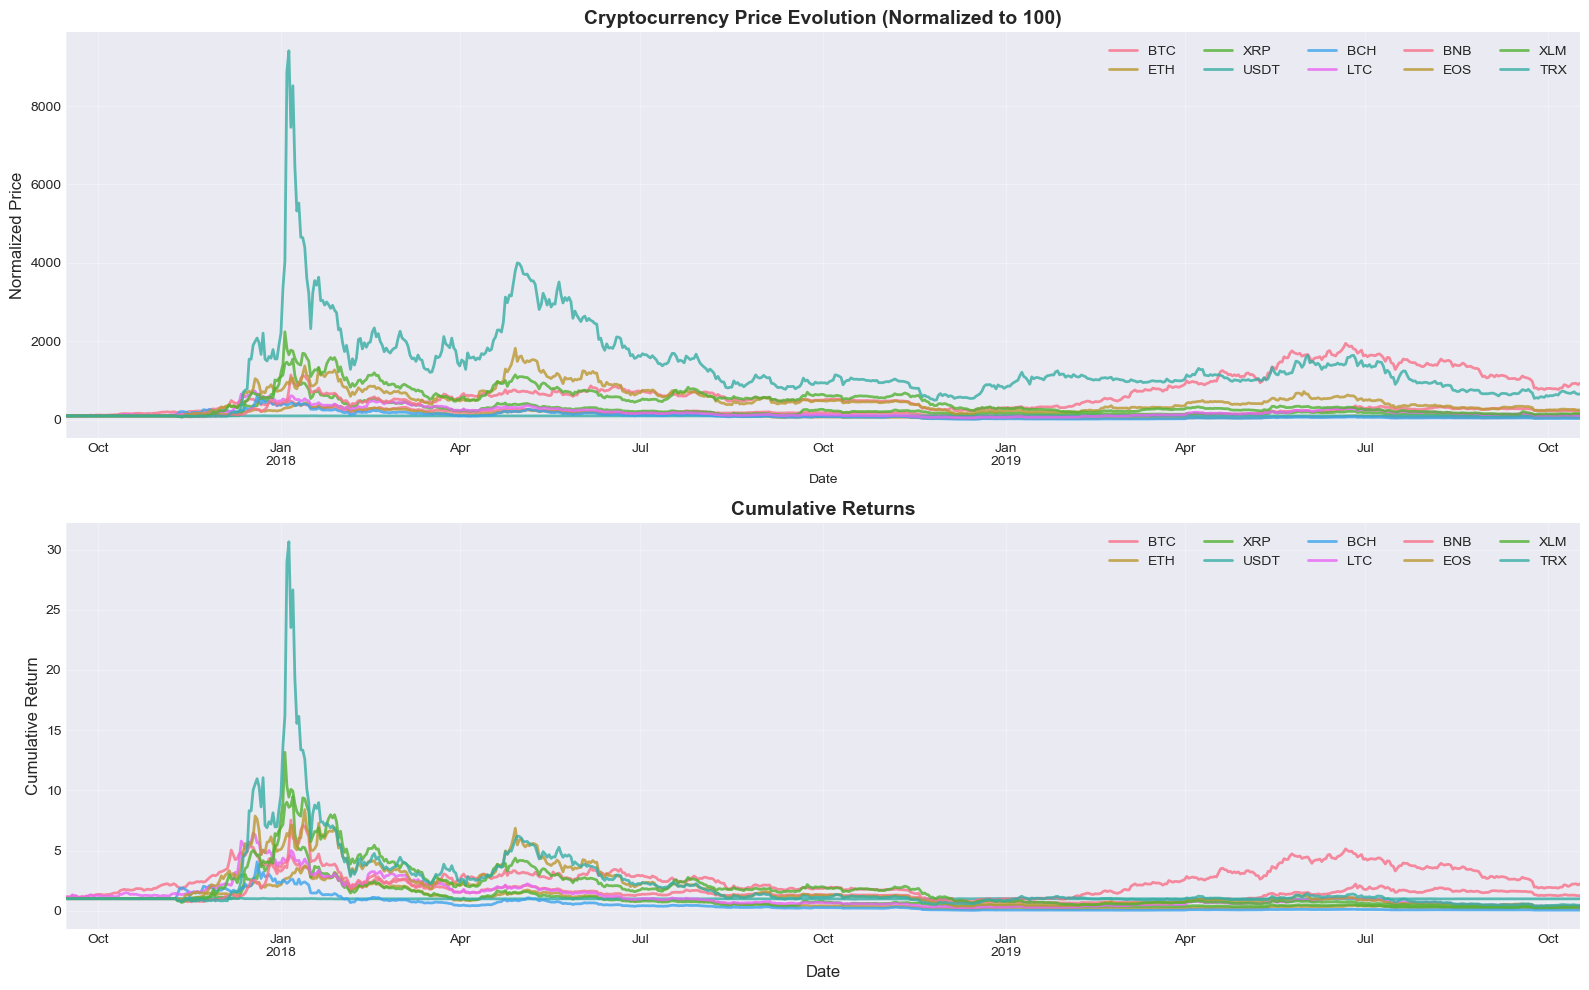

In [3]:
# Visualize price evolution
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Normalized prices (starting at 100)
df_prices_norm = df_prices / df_prices.iloc[0] * 100
df_prices_norm.plot(ax=axes[0], linewidth=2, alpha=0.8)
axes[0].set_title('Cryptocurrency Price Evolution (Normalized to 100)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Normalized Price', fontsize=12)
axes[0].legend(loc='best', ncol=5)
axes[0].grid(True, alpha=0.3)

# Cumulative returns
df_cumret = (1 + df_returns).cumprod()
df_cumret.plot(ax=axes[1], linewidth=2, alpha=0.8)
axes[1].set_title('Cumulative Returns', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cumulative Return', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend(loc='best', ncol=5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

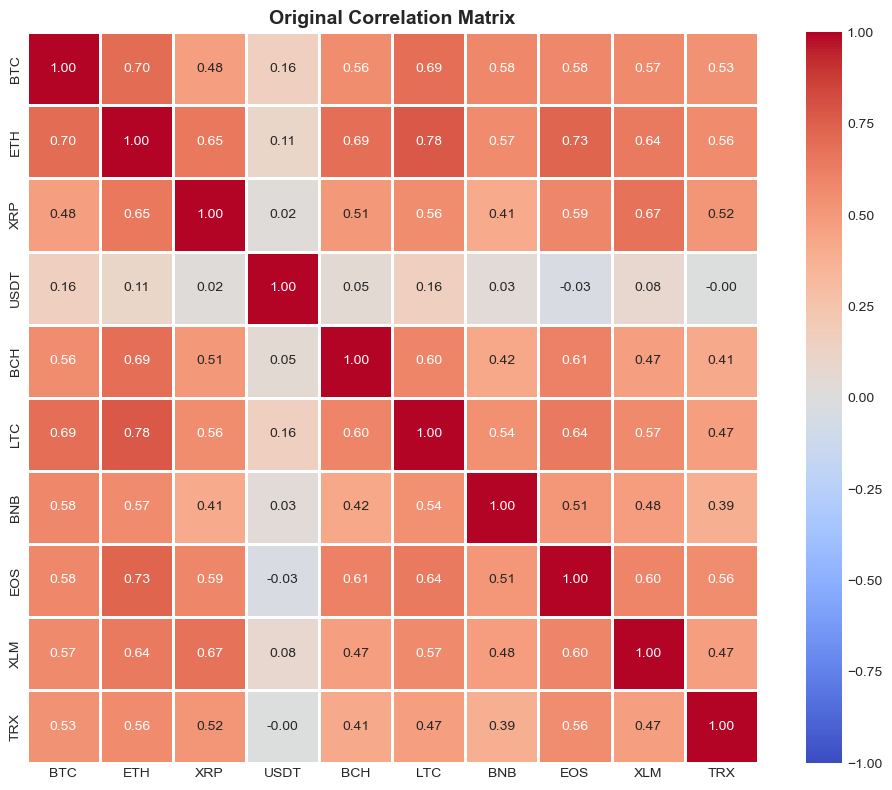

In [4]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr_original, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True, linewidths=1)
plt.title('Original Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Random Matrix Theory (RMT) - Filter Correlation Matrix

In [5]:
def apply_rmt_filter(returns_data):
    """
    Apply Random Matrix Theory filtering using Marchenko-Pastur distribution
    
    Parameters:
    -----------
    returns_data : pd.DataFrame
        Returns data (T x N)
    
    Returns:
    --------
    C_filtered : np.ndarray
        Filtered correlation matrix
    eigenvalues : np.ndarray
        Eigenvalues (sorted descending)
    lambda_plus : float
        Marchenko-Pastur upper bound
    """
    T, N = returns_data.shape
    Q = T / N  # Ratio
    
    # Compute correlation matrix
    C = np.corrcoef(returns_data.T)
    
    # Eigenvalue decomposition
    eigenvalues, eigenvectors = eigh(C)
    eigenvalues = eigenvalues[::-1]  # Sort descending
    eigenvectors = eigenvectors[:, ::-1]
    
    # Marchenko-Pastur bounds
    lambda_plus = 1 + (1/Q) + 2*np.sqrt(1/Q)
    lambda_minus = 1 + (1/Q) - 2*np.sqrt(1/Q)
    
    print(f"📊 RMT Analysis:")
    print(f"   Q = T/N = {T}/{N} = {Q:.2f}")
    print(f"   λ+ (threshold) = {lambda_plus:.4f}")
    print(f"   λ- (lower bound) = {lambda_minus:.4f}")
    print(f"\n   Eigenvalues: {eigenvalues.round(4)}")
    
    # Filter: keep only eigenvalues > lambda_plus
    significant_mask = eigenvalues > lambda_plus
    n_significant = significant_mask.sum()
    
    print(f"\n   ✅ Significant eigenvalues: {n_significant}/{N}")
    print(f"   ❌ Filtered out (noise): {N - n_significant}/{N}")
    
    # Reconstruct filtered correlation matrix
    Lambda_filtered = np.diag(np.where(significant_mask, eigenvalues, 0))
    C_filtered = eigenvectors @ Lambda_filtered @ eigenvectors.T
    
    return C_filtered, eigenvalues, lambda_plus

# Apply RMT on a 120-day window (as in paper)
window_size = 120
window_data = df_returns.iloc[:window_size]

print(f"\n🔍 Applying RMT filter on first {window_size} days...\n")
C_filtered, eigenvals, threshold = apply_rmt_filter(window_data)


🔍 Applying RMT filter on first 120 days...

📊 RMT Analysis:
   Q = T/N = 120/10 = 12.00
   λ+ (threshold) = 1.6607
   λ- (lower bound) = 0.5060

   Eigenvalues: [3.1358 1.4186 1.1853 1.0512 0.9083 0.639  0.5522 0.4887 0.3602 0.2607]

   ✅ Significant eigenvalues: 1/10
   ❌ Filtered out (noise): 9/10


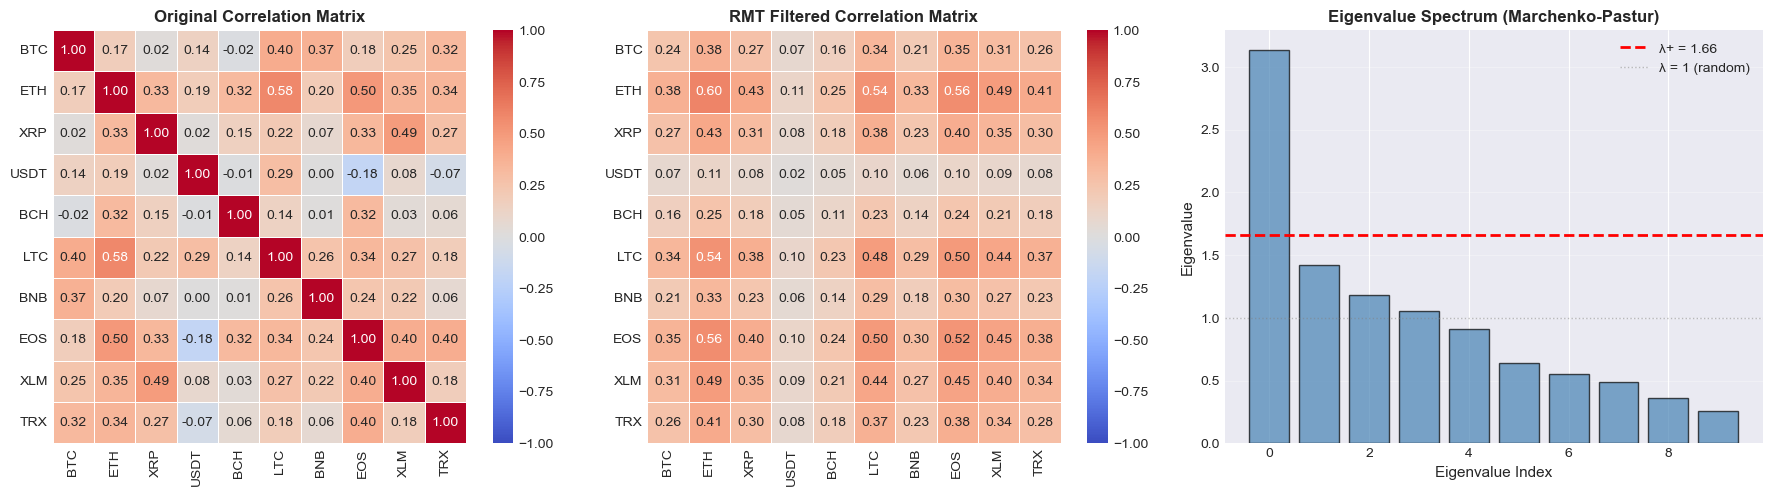

In [6]:
# Visualize RMT filtering
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original correlation
sns.heatmap(np.corrcoef(window_data.T), annot=True, fmt='.2f', cmap='coolwarm', 
            xticklabels=crypto_names, yticklabels=crypto_names, ax=axes[0], 
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5)
axes[0].set_title('Original Correlation Matrix', fontsize=12, fontweight='bold')

# Filtered correlation
sns.heatmap(C_filtered, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=crypto_names, yticklabels=crypto_names, ax=axes[1], 
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5)
axes[1].set_title('RMT Filtered Correlation Matrix', fontsize=12, fontweight='bold')

# Eigenvalue spectrum
axes[2].bar(range(len(eigenvals)), eigenvals, alpha=0.7, color='steelblue', edgecolor='black')
axes[2].axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'λ+ = {threshold:.2f}')
axes[2].axhline(y=1, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='λ = 1 (random)')
axes[2].set_xlabel('Eigenvalue Index', fontsize=11)
axes[2].set_ylabel('Eigenvalue', fontsize=11)
axes[2].set_title('Eigenvalue Spectrum (Marchenko-Pastur)', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Minimal Spanning Tree (MST)

In [7]:
def build_mst(correlation_matrix, asset_names):
    """
    Build Minimal Spanning Tree from correlation matrix
    Distance metric: d_ij = sqrt(2 - 2*c_ij)
    
    Parameters:
    -----------
    correlation_matrix : np.ndarray
        Correlation matrix (N x N)
    asset_names : list
        List of asset names
    
    Returns:
    --------
    G : nx.Graph
        NetworkX graph representing MST
    distance_matrix : np.ndarray
        Distance matrix
    """
    # Convert correlation to distance
    distance_matrix = np.sqrt(2 - 2*correlation_matrix)
    np.fill_diagonal(distance_matrix, 0)
    
    # Compute MST using Kruskal's algorithm
    mst = minimum_spanning_tree(distance_matrix)
    mst_full = mst.toarray()
    
    # Create NetworkX graph for visualization
    G = nx.Graph()
    for i, name in enumerate(asset_names):
        G.add_node(name)
    
    for i in range(len(asset_names)):
        for j in range(i+1, len(asset_names)):
            if mst_full[i, j] > 0 or mst_full[j, i] > 0:
                weight = max(mst_full[i, j], mst_full[j, i])
                G.add_edge(asset_names[i], asset_names[j], weight=weight)
    
    print(f"\n🌳 MST Construction:")
    print(f"   Nodes: {G.number_of_nodes()}")
    print(f"   Edges: {G.number_of_edges()} (should be {len(asset_names)-1})")
    print(f"   Total distance: {sum([d['weight'] for u, v, d in G.edges(data=True)]):.4f}")
    
    return G, distance_matrix

# Build MST from filtered correlation
G_mst, dist_matrix = build_mst(C_filtered, crypto_names)


🌳 MST Construction:
   Nodes: 10
   Edges: 9 (should be 9)
   Total distance: 9.8932


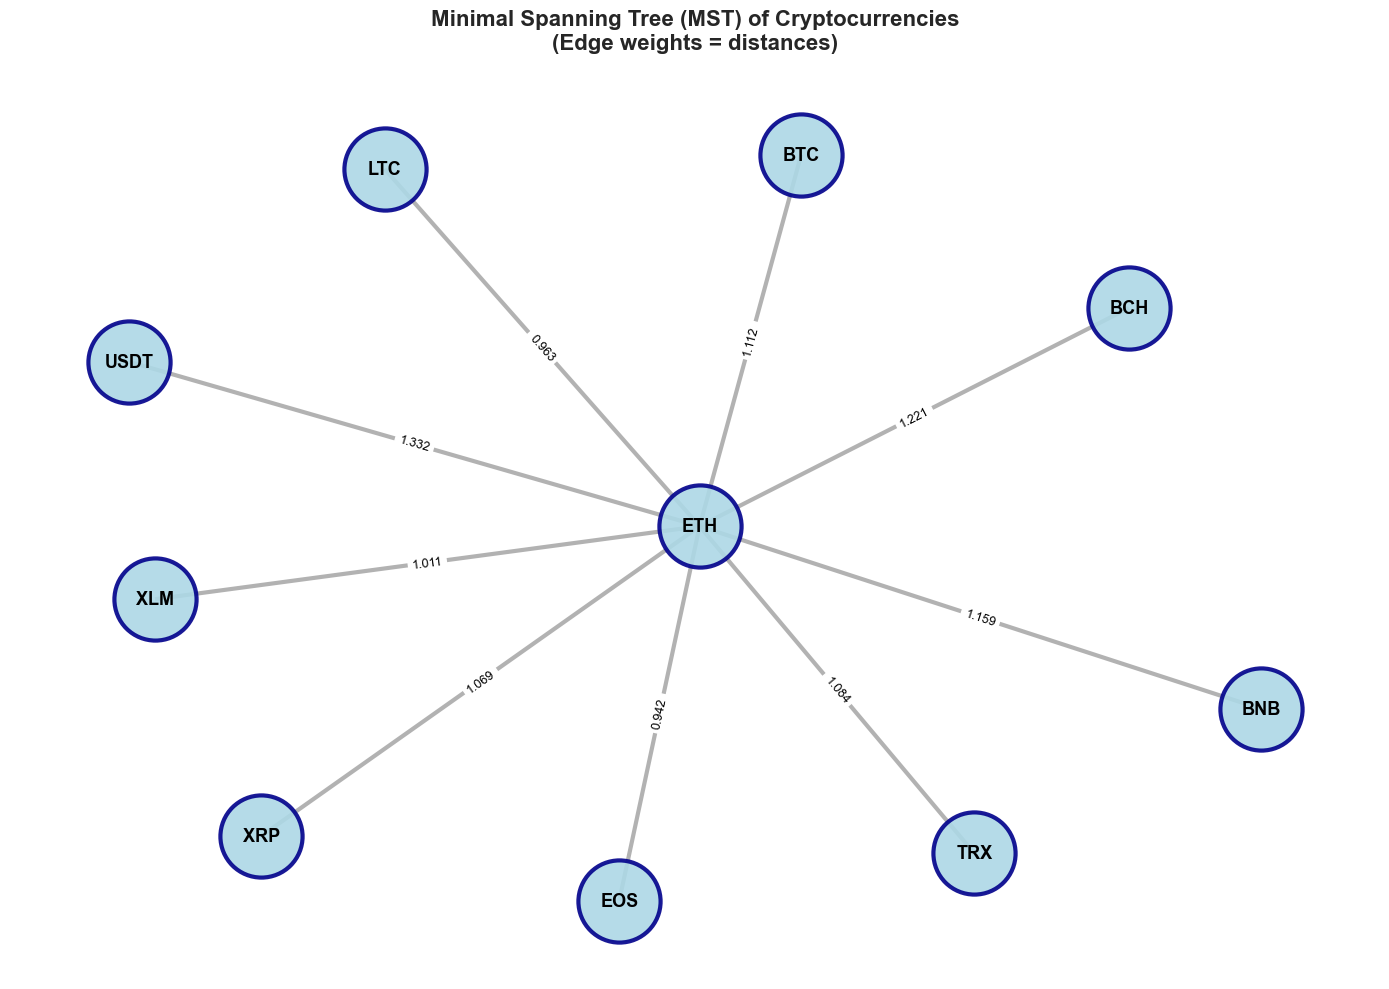

In [8]:
# Visualize MST
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G_mst, k=2, iterations=50, seed=42)

# Draw nodes
nx.draw_networkx_nodes(G_mst, pos, node_size=3500, node_color='lightblue', 
                       edgecolors='darkblue', linewidths=3, alpha=0.9)

# Draw labels
nx.draw_networkx_labels(G_mst, pos, font_size=13, font_weight='bold', font_family='sans-serif')

# Draw edges with varying thickness based on weight
edges = G_mst.edges()
weights = [G_mst[u][v]['weight'] for u, v in edges]
nx.draw_networkx_edges(G_mst, pos, width=3, alpha=0.6, edge_color='gray')

# Edge labels
edge_labels = nx.get_edge_attributes(G_mst, 'weight')
edge_labels = {k: f"{v:.3f}" for k, v in edge_labels.items()}
nx.draw_networkx_edge_labels(G_mst, pos, edge_labels, font_size=9)

plt.title('Minimal Spanning Tree (MST) of Cryptocurrencies\n(Edge weights = distances)', 
          fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Network Centrality (Eigenvector Centrality)

In [9]:
def compute_eigenvector_centrality(distance_matrix):
    """
    Compute eigenvector centrality from distance matrix
    
    Interpretation:
    - Higher centrality = more different from others = higher systemic risk
    - Lower centrality = more similar to others = peripheral assets
    
    Parameters:
    -----------
    distance_matrix : np.ndarray
        Distance matrix (N x N)
    
    Returns:
    --------
    centrality : np.ndarray
        Normalized centrality scores
    """
    # Create adjacency matrix (inverse of distance)
    adjacency = 1 / (distance_matrix + 1e-8)
    np.fill_diagonal(adjacency, 0)
    
    # Compute eigenvector centrality (principal eigenvector)
    eigenvalues, eigenvectors = eigh(adjacency)
    principal_eigenvector = np.abs(eigenvectors[:, -1])
    
    # Normalize to sum to 1
    centrality = principal_eigenvector / principal_eigenvector.sum()
    
    return centrality

centrality_scores = compute_eigenvector_centrality(dist_matrix)

print("\n📊 Network Centrality Scores:")
print("   (Higher = More Systemic Risk)\n")
for crypto, score in zip(crypto_names, centrality_scores):
    print(f"   {crypto:6s}: {score:.6f}")


📊 Network Centrality Scores:
   (Higher = More Systemic Risk)

   BTC   : 0.098421
   ETH   : 0.108299
   XRP   : 0.100474
   USDT  : 0.088455
   BCH   : 0.093395
   LTC   : 0.105417
   BNB   : 0.096230
   EOS   : 0.106340
   XLM   : 0.103186
   TRX   : 0.099782


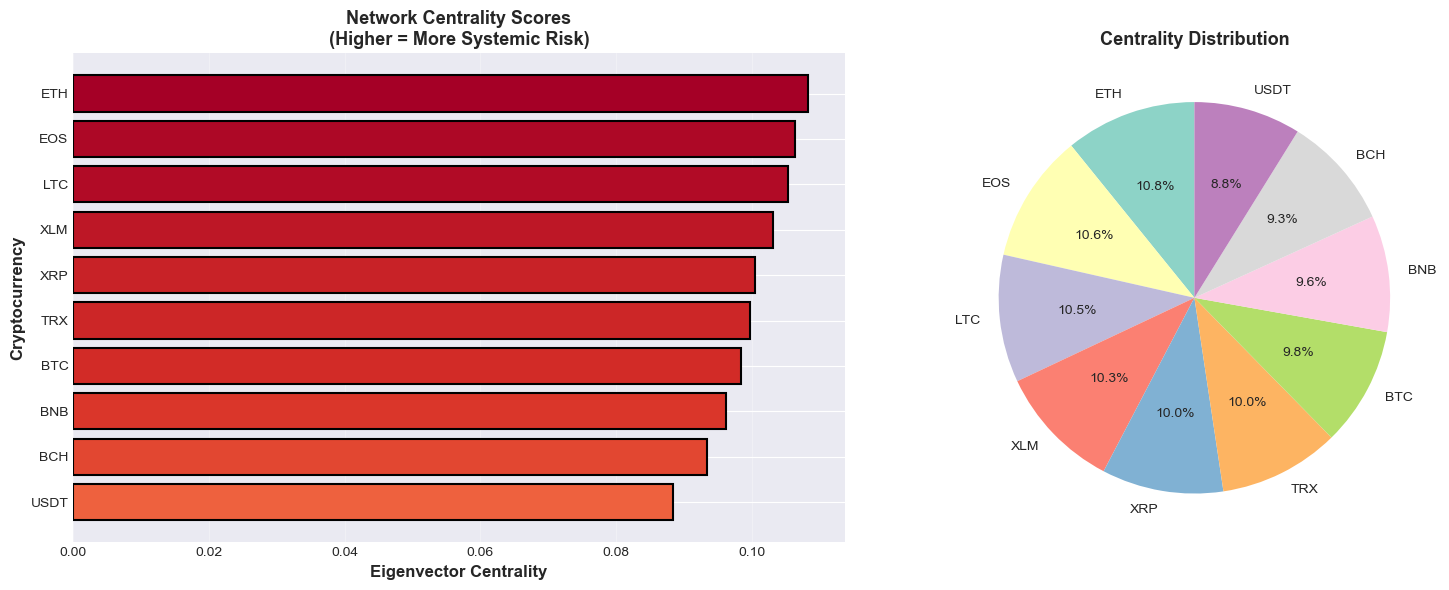

In [10]:
# Visualize centrality
centrality_df = pd.DataFrame({
    'Asset': crypto_names,
    'Centrality': centrality_scores
}).sort_values('Centrality', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = plt.cm.RdYlGn_r(centrality_df['Centrality'] / centrality_df['Centrality'].max())
axes[0].barh(centrality_df['Asset'], centrality_df['Centrality'], color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Eigenvector Centrality', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cryptocurrency', fontsize=12, fontweight='bold')
axes[0].set_title('Network Centrality Scores\n(Higher = More Systemic Risk)', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Pie chart
axes[1].pie(centrality_df['Centrality'], labels=centrality_df['Asset'], autopct='%1.1f%%',
           startangle=90, colors=plt.cm.Set3(range(len(centrality_df))))
axes[1].set_title('Centrality Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Portfolio Optimization - Network Markowitz

### Objective Function:
$$\min_w w^T \Sigma^* w + \gamma \sum_{i=1}^{n} x_i w_i$$

**Where:**
- $w$ = portfolio weights
- $\Sigma^*$ = filtered covariance matrix (RMT + MST)
- $\gamma$ = systemic risk aversion parameter
- $x_i$ = eigenvector centrality of asset $i$

**Constraints:**
- $\sum_{i=1}^{n} w_i = 1$ (fully invested)
- $w_i \geq 0$ (no short selling)
- $\mu_P \geq \bar{\mu}$ (minimum return constraint)

In [11]:
def network_markowitz_optimization(returns_data, correlation_filtered, centrality, gamma=0):
    """
    Network Markowitz Portfolio Optimization
    
    Parameters:
    -----------
    returns_data : pd.DataFrame
        Historical returns
    correlation_filtered : np.ndarray
        RMT filtered correlation matrix
    centrality : np.ndarray
        Eigenvector centrality scores
    gamma : float
        Systemic risk aversion parameter
    
    Returns:
    --------
    weights : np.ndarray
        Optimal portfolio weights
    portfolio_return : float
        Expected portfolio return
    portfolio_risk : float
        Portfolio volatility (std dev)
    """
    n_assets = returns_data.shape[1]
    
    # Compute filtered covariance matrix
    std_devs = returns_data.std().values
    cov_filtered = np.outer(std_devs, std_devs) * correlation_filtered
    
    # Mean returns
    mean_returns = returns_data.mean().values
    
    # Objective function: portfolio variance + centrality penalty
    def objective(w):
        portfolio_variance = w @ cov_filtered @ w
        centrality_penalty = gamma * np.sum(centrality * w)
        return portfolio_variance + centrality_penalty
    
    # Constraints
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},  # weights sum to 1
        {'type': 'ineq', 'fun': lambda w: w @ mean_returns - mean_returns.mean()}  # min return
    ]
    
    # Bounds: w_i >= 0 (no short selling)
    bounds = tuple((0, 1) for _ in range(n_assets))
    
    # Initial guess: equal weights
    w0 = np.ones(n_assets) / n_assets
    
    # Optimize
    result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
    
    if result.success:
        weights = result.x
        portfolio_return = weights @ mean_returns
        portfolio_risk = np.sqrt(weights @ cov_filtered @ weights)
        return weights, portfolio_return, portfolio_risk
    else:
        print(f"⚠️ Optimization failed: {result.message}")
        return None, None, None

In [12]:
# Test different gamma values (as in paper)
gamma_values = [0, 0.005, 0.025, 0.05, 0.15, 0.7, 1.0]
results = []

print("\n" + "="*90)
print("NETWORK MARKOWITZ OPTIMIZATION RESULTS")
print("="*90)

for gamma in gamma_values:
    weights, ret, risk = network_markowitz_optimization(window_data, C_filtered, centrality_scores, gamma)
    
    if weights is not None:
        # Annualize metrics (252 trading days)
        annual_return = ret * 252
        annual_risk = risk * np.sqrt(252)
        sharpe = annual_return / annual_risk if annual_risk > 0 else 0
        
        results.append({
            'gamma': gamma,
            'weights': weights,
            'return': annual_return,
            'risk': annual_risk,
            'sharpe': sharpe
        })
        
        print(f"\n{'─'*90}")
        print(f"γ = {gamma:.3f}" + (" (Network Markowitz - No Centrality Penalty)" if gamma == 0 else ""))
        print(f"{'─'*90}")
        print(f"  📈 Annual Return:  {annual_return*100:>8.2f}%")
        print(f"  📉 Annual Risk:    {annual_risk*100:>8.2f}%")
        print(f"  📊 Sharpe Ratio:   {sharpe:>8.4f}")
        print(f"\n  💼 Top 5 Holdings:")
        top_idx = np.argsort(weights)[-5:][::-1]
        for rank, idx in enumerate(top_idx, 1):
            if weights[idx] > 0.001:  # Only show if weight > 0.1%
                print(f"     {rank}. {crypto_names[idx]:6s}: {weights[idx]*100:>6.2f}%")

print(f"\n{'='*90}")


NETWORK MARKOWITZ OPTIMIZATION RESULTS

──────────────────────────────────────────────────────────────────────────────────────────
γ = 0.000 (Network Markowitz - No Centrality Penalty)
──────────────────────────────────────────────────────────────────────────────────────────
  📈 Annual Return:    415.24%
  📉 Annual Risk:       52.86%
  📊 Sharpe Ratio:     7.8562

  💼 Top 5 Holdings:
     1. BNB   :  65.90%
     2. BTC   :  24.55%
     3. USDT  :   8.15%
     4. BCH   :   1.40%

──────────────────────────────────────────────────────────────────────────────────────────
γ = 0.005
──────────────────────────────────────────────────────────────────────────────────────────
  📈 Annual Return:    415.24%
  📉 Annual Risk:       52.78%
  📊 Sharpe Ratio:     7.8667

  💼 Top 5 Holdings:
     1. BNB   :  66.51%
     2. BTC   :  23.55%
     3. USDT  :   8.54%
     4. BCH   :   1.40%

──────────────────────────────────────────────────────────────────────────────────────────
γ = 0.025
────────────────

## 7. Visualization: Portfolio Weights Across Different γ

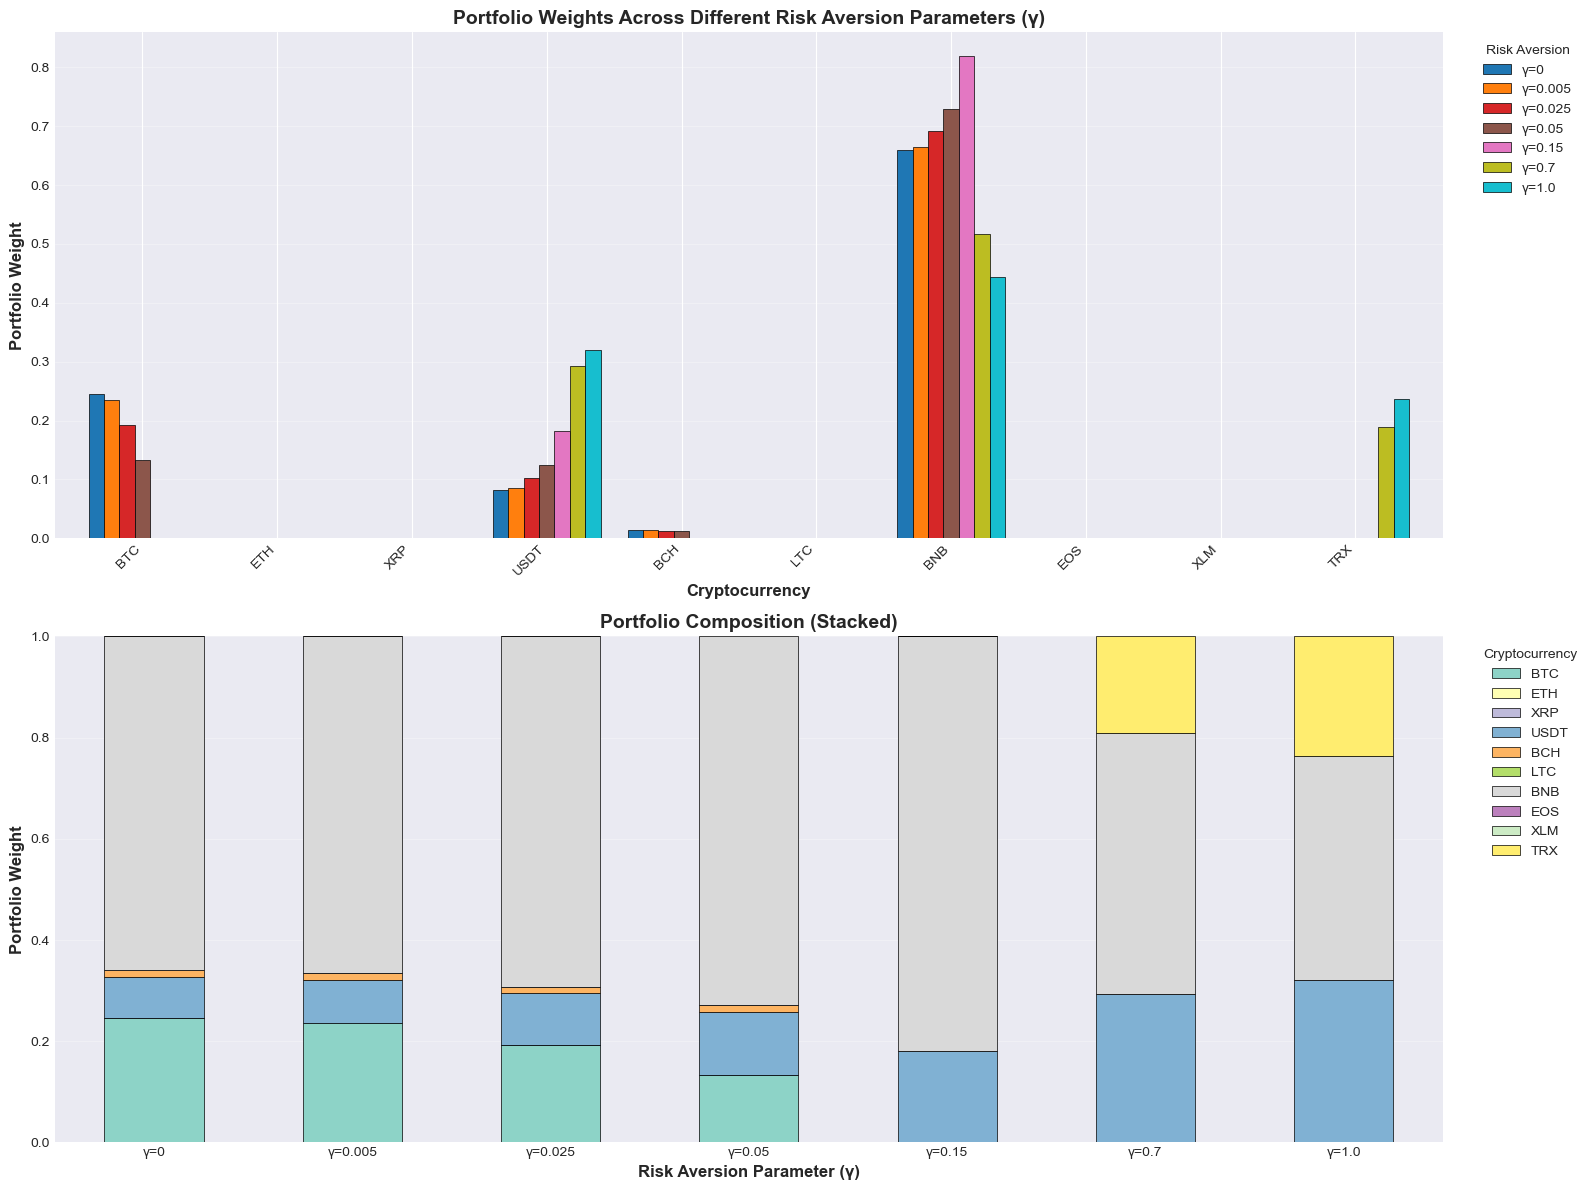


📊 Portfolio Weights Table:
            BTC  ETH  XRP    USDT     BCH  LTC     BNB  EOS  XLM     TRX
γ=0      0.2455  0.0  0.0  0.0815  0.0140  0.0  0.6590  0.0  0.0  0.0000
γ=0.005  0.2355  0.0  0.0  0.0854  0.0140  0.0  0.6651  0.0  0.0  0.0000
γ=0.025  0.1927  0.0  0.0  0.1021  0.0133  0.0  0.6919  0.0  0.0  0.0000
γ=0.05   0.1327  0.0  0.0  0.1252  0.0129  0.0  0.7291  0.0  0.0  0.0000
γ=0.15   0.0000  0.0  0.0  0.1817  0.0000  0.0  0.8183  0.0  0.0  0.0000
γ=0.7    0.0000  0.0  0.0  0.2933  0.0000  0.0  0.5168  0.0  0.0  0.1899
γ=1.0    0.0000  0.0  0.0  0.3203  0.0000  0.0  0.4438  0.0  0.0  0.2359


In [13]:
# Create weights dataframe
weights_df = pd.DataFrame(
    [res['weights'] for res in results],
    columns=crypto_names,
    index=[f"γ={res['gamma']}" for res in results]
)

# Stacked bar chart
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Grouped bar chart
weights_df.T.plot(kind='bar', ax=axes[0], width=0.8, colormap='tab10', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Cryptocurrency', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Portfolio Weight', fontsize=12, fontweight='bold')
axes[0].set_title('Portfolio Weights Across Different Risk Aversion Parameters (γ)', 
                  fontsize=14, fontweight='bold')
axes[0].legend(title='Risk Aversion', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(crypto_names, rotation=45, ha='right')

# Stacked area chart
weights_df.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3', edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Risk Aversion Parameter (γ)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Portfolio Weight', fontsize=12, fontweight='bold')
axes[1].set_title('Portfolio Composition (Stacked)', fontsize=14, fontweight='bold')
axes[1].legend(title='Cryptocurrency', bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1)
axes[1].set_xticklabels([f"γ={g}" for g in gamma_values], rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Portfolio Weights Table:")
print(weights_df.round(4))

## 8. Efficient Frontier & Risk-Return Analysis

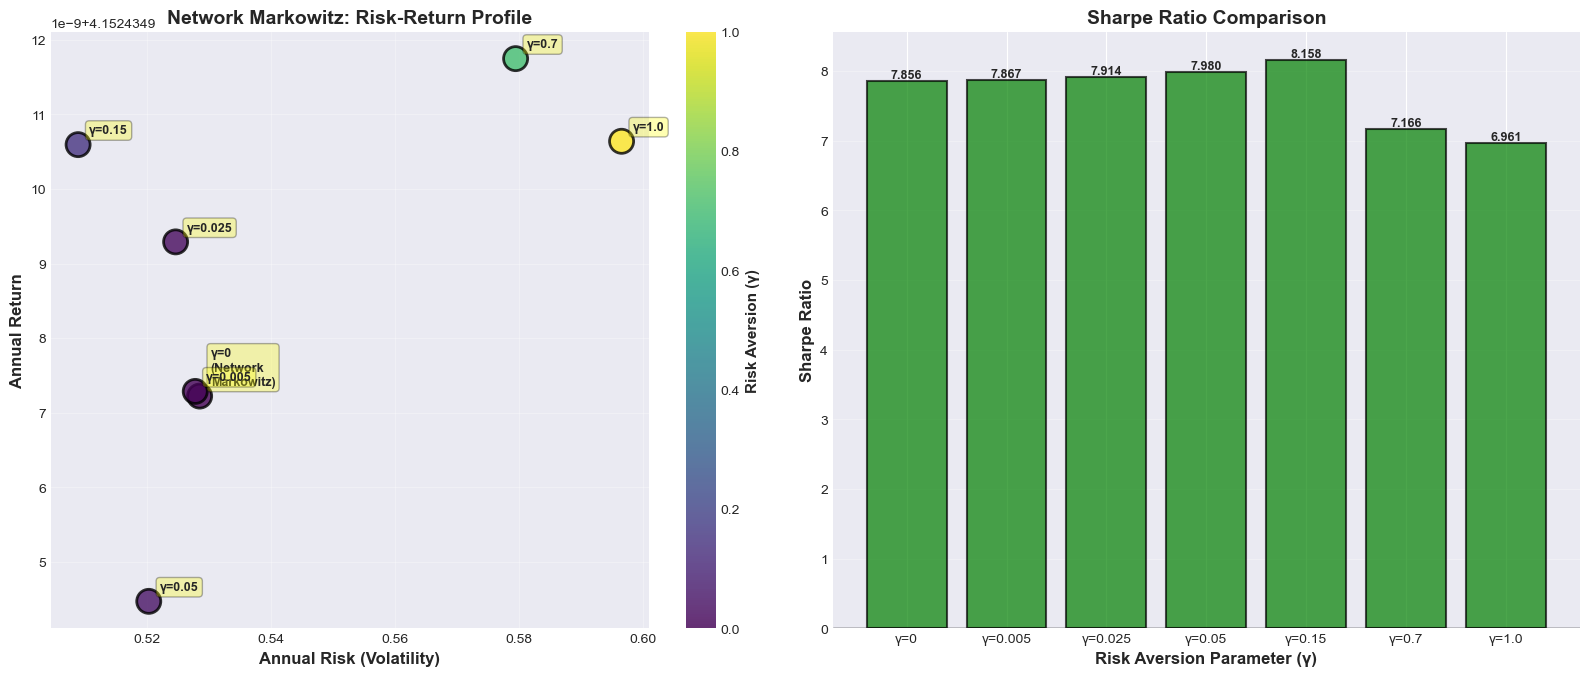

In [14]:
# Extract metrics
risks = [res['risk'] for res in results]
returns = [res['return'] for res in results]
gammas = [res['gamma'] for res in results]
sharpes = [res['sharpe'] for res in results]

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Risk-Return scatter (colored by gamma)
scatter = axes[0].scatter(risks, returns, c=gammas, s=300, cmap='viridis', 
                         edgecolors='black', linewidths=2, alpha=0.8, zorder=3)

# Annotate points
for i, (r, ret, g) in enumerate(zip(risks, returns, gammas)):
    label = f'γ={g}'
    if g == 0:
        label += '\n(Network\nMarkowitz)'
    axes[0].annotate(label, (r, ret), xytext=(8, 8), textcoords='offset points', 
                    fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Risk Aversion (γ)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Annual Risk (Volatility)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Annual Return', fontsize=12, fontweight='bold')
axes[0].set_title('Network Markowitz: Risk-Return Profile', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Sharpe Ratio comparison
colors_sharpe = ['green' if s > 0 else 'red' for s in sharpes]
bars = axes[1].bar([f'γ={g}' for g in gammas], sharpes, color=colors_sharpe, 
                   edgecolor='black', linewidth=1.5, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Risk Aversion Parameter (γ)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Sharpe Ratio', fontsize=12, fontweight='bold')
axes[1].set_title('Sharpe Ratio Comparison', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, sharpe in zip(bars, sharpes):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{sharpe:.3f}', ha='center', va='bottom' if height > 0 else 'top',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Export Results to Excel

In [15]:
# Prepare results for export
results_summary = pd.DataFrame({
    'Gamma': [res['gamma'] for res in results],
    'Annual_Return_%': [res['return']*100 for res in results],
    'Annual_Risk_%': [res['risk']*100 for res in results],
    'Sharpe_Ratio': [res['sharpe'] for res in results]
})

# Export to Excel
output_file = 'network_markowitz_results.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # Summary metrics
    results_summary.to_excel(writer, sheet_name='Summary', index=False)
    
    # Portfolio weights
    weights_df.to_excel(writer, sheet_name='Portfolio_Weights')
    
    # Centrality scores
    centrality_df.to_excel(writer, sheet_name='Centrality', index=False)
    
    # Filtered correlation
    pd.DataFrame(C_filtered, columns=crypto_names, index=crypto_names).to_excel(
        writer, sheet_name='Filtered_Correlation')
    
    # Distance matrix
    pd.DataFrame(dist_matrix, columns=crypto_names, index=crypto_names).to_excel(
        writer, sheet_name='Distance_Matrix')

print(f"\n✅ Results exported to: {output_file}")
print("\n📊 Summary:")
print(results_summary.round(4))


✅ Results exported to: network_markowitz_results.xlsx

📊 Summary:
   Gamma  Annual_Return_%  Annual_Risk_%  Sharpe_Ratio
0  0.000         415.2435        52.8556        7.8562
1  0.005         415.2435        52.7848        7.8667
2  0.025         415.2435        52.4688        7.9141
3  0.050         415.2435        52.0360        7.9799
4  0.150         415.2435        50.8977        8.1584
5  0.700         415.2435        57.9456        7.1661
6  1.000         415.2435        59.6527        6.9610


## 10. Summary & Key Insights

### 📚 **Metodologi Paper (Giudici et al., 2020):**

1. **Random Matrix Theory (RMT)**
   - Memfilter noise dari correlation matrix
   - Menggunakan Marchenko-Pastur distribution
   - Hanya eigenvalue > λ+ yang dianggap signifikan

2. **Minimal Spanning Tree (MST)**
   - Menyederhanakan struktur jaringan dari N(N-1)/2 edges → N-1 edges
   - Distance metric: d_ij = √(2 - 2c_ij)
   - Menghubungkan aset yang paling mirip

3. **Network Centrality**
   - Eigenvector centrality mengukur systemic risk
   - Higher centrality = lebih berbeda dari aset lain = higher risk
   - Lower centrality = peripheral assets = lower systemic risk

4. **Portfolio Optimization**
   - Markowitz + centrality penalty
   - Parameter γ mengontrol risk aversion terhadap systemic risk

### 🎯 **Parameter γ (Risk Aversion):**

- **γ = 0**: Network Markowitz (RMT+MST only)
  - ✅ Terbaik untuk **bear market** (proteksi downside)
  - ✅ Risiko lebih rendah
  - ❌ Return lebih rendah di bull market

- **γ > 0**: Dengan centrality penalty
  - ✅ Terbaik untuk **bull market** (adaptif)
  - ✅ Return lebih tinggi saat kondisi baik
  - ❌ Risiko lebih tinggi
  - Semakin besar γ → semakin avoid high-centrality assets

### 💡 **Temuan Paper:**

1. **Bull Market**: Model dengan γ > 0 beradaptasi cepat dan menghasilkan return lebih baik
2. **Bear Market**: γ = 0 memberikan proteksi terbaik terhadap kerugian
3. **Risk Management**: VaR lebih rendah dibanding benchmark (CRIX, Equal Weight)
4. **Sharpe Ratio**: Kompetitif dengan Classical Markowitz

### 🔬 **Relevansi dengan Thesis Anda:**

Paper ini adalah **SOTA baseline** yang bagus untuk dibandingkan dengan strategi Anda:

| Aspek | Giudici et al. (2020) | Thesis Anda |
|-------|----------------------|-------------|
| **Filtering** | RMT + MST | RMT + MST ✅ |
| **Centrality** | Eigenvector | Network centrality ✅ |
| **Regime Detection** | ❌ Manual | ✅ **Momentum-based** |
| **Asset Selection** | All assets | ✅ **Graph filtering (MIS)** |
| **Adaptive Strategy** | ❌ Fixed γ | ✅ **Bull/Bear adaptive** |
| **Statistical Testing** | ❌ None | ✅ **Significance tests** |

**Kekuatan Anda:**
- ✅ Automatic regime detection
- ✅ Dynamic asset selection
- ✅ Adaptive strategy (clustering vs diversification)
- ✅ Statistical rigor